# Cognitive Test Bias: Monolingual vs. Bilingual Classification
**Course:** DATASCI 223 — Final Project  
**Author:** Derek Malvin

In [ ]:
%pip install -q pandas numpy scipy scikit-learn matplotlib seaborn xgboost

Note: you may need to restart the kernel to use updated packages.


## 1. Load and Clean Data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

#Load Dataset and Key Cognitive Tests from Test Battery
DATA = "final_branchsummer2025_dataset_2025-12-02.csv"

KEY_VARIABLES = [
    "mmse_tot.bedside",        #MMSE
    "corr10.bedside",          #CVLT-2
    "mt_time.bedside",         #Modified Trails time
    "mt_corr.bedside",         #Modified Trails correct
    "df_corr.bedside",         #Design Fluency
    "mod_rey.bedside",         #Modified Rey
    "digit_fw.bedside",        #Digits Forward
    "digit_bw.bedside",        #Digits Backward
    "wrat_tot.bedside",        #WRAT
    "d_corr.bedside",          #D word Fluency
    "an_corr.bedside",         #Animal Fluency
    "rey10m.bedside",          #Modified Rey Recall
    "bnt_tot.bedside",         #Boston Naming
    "strp_cn_cor.bedside",     #Stroop Color Naming
    "strp_cor.bedside",        #Stroop Interference
    "numb_loc.bedside",        #VOSP
    "gds_tot.bedside",         #Geriatric Depression Scale
    "cv2lfrc.bedside",         #CVLT-II
    "memoryzscore.bedside",    #Memory z-score
    "bsexzscore.bedside",      #Executive functioning z-score
    "cdr_box.cdr",             #CDR Sum of Boxes
    "ftld_cdr_box.cdr"         #FTLD CDR Sum of Boxes
]

LANG_TEST = "testing_language.demographics"
PRIM_LANG = "primary_language.demographics"
MIN_N = 50   #Minimum sample size threshold to ensure stable effect size estimates

print(f"Configured {len(KEY_VARIABLES)} key variables")


Configured 22 key variables


In [3]:
df = pd.read_csv(DATA)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

#Replace negative values (missing data codes) with NaN
clean_df = df.copy()
for var in KEY_VARIABLES:
    if var in clean_df.columns:
        neg_count = (clean_df[var] < 0).sum()
        if neg_count > 0:
            print(f"  {var}: replacing {neg_count} negative values -> NaN")
        clean_df.loc[clean_df[var] < 0, var] = np.nan
    else:
        print(f"  WARNING: '{var}' not found in dataset")

print("\nCleaning complete.")


Loaded: 5175 rows, 3912 columns
  memoryzscore.bedside: replacing 1242 negative values -> NaN
  bsexzscore.bedside: replacing 1730 negative values -> NaN

Cleaning complete.


In [4]:
#Filter to English-tested participants only
eng = clean_df[clean_df[LANG_TEST] == "English"].copy()

#Assign group: Monolingual vs Bilingual
eng["group"] = np.where(eng[PRIM_LANG] == "English", "Monolingual", "Bilingual")

print("Sample sizes after filtering:")
print(eng["group"].value_counts().to_string())
print(f"\nTotal English-tested: {len(eng)}")


Sample sizes after filtering:
group
Monolingual    1779
Bilingual       185

Total English-tested: 1964


## 2. Explore the Data

In [5]:
#Check how many valid observations each variable has per group
mono = eng[eng["group"] == "Monolingual"]
bi   = eng[eng["group"] == "Bilingual"]

available = []
for var in KEY_VARIABLES:
    if var in eng.columns and eng[var].notna().sum() >= MIN_N:
        available.append({
            "variable": var,
            "n_total":  eng[var].notna().sum(),
            "n_mono":   mono[var].notna().sum(),
            "n_bi":     bi[var].notna().sum(),
            "mono_mean": round(mono[var].mean(), 2),
            "bi_mean":   round(bi[var].mean(), 2)
        })

available_df = pd.DataFrame(available)
print(f"Variables with n >= {MIN_N}: {len(available_df)}")
display(available_df)


Variables with n >= 50: 22


,variable,n_total,n_mono,n_bi,mono_mean,bi_mean
0,mmse_tot.bedside,1356,1277,79,28.97,27.80
1,corr10.bedside,304,257,47,7.04,7.23
2,mt_time.bedside,1432,1331,101,30.51,46.05
3,mt_corr.bedside,1436,1335,101,13.75,13.95
4,df_corr.bedside,1416,1307,109,11.58,9.62
5,mod_rey.bedside,1315,1209,106,15.42,15.43
6,digit_fw.bedside,1271,1197,74,6.86,5.92
7,digit_bw.bedside,1340,1264,76,5.39,4.42
8,wrat_tot.bedside,547,501,46,64.86,62.93
9,d_corr.bedside,1243,1173,70,16.04,13.69


## 3. Cohen's d Bias Analysis

**Classification Logic**

| Cohen's d | Bias level |
|---|---|
| p ≥ 0.05 OR d < 0.2 | FAIR |
| 0.2 ≤ d < 0.5 | SMALL BIAS |
| 0.5 ≤ d < 0.8 | MEDIUM BIAS |
| d ≥ 0.8 | LARGE BIAS |


In [ ]:
#Pooled Cohen's d
#x1 = Monolingual, x2 = Bilingual
def cohens_d(x1, x2):
    x1 = x1[~np.isnan(x1)]
    x2 = x2[~np.isnan(x2)]
    n1, n2 = len(x1), len(x2)
    pooled_sd = np.sqrt(
        ((n1 - 1) * np.var(x1, ddof=1) + (n2 - 1) * np.var(x2, ddof=1))
        / (n1 + n2 - 2)
    )
    return (np.mean(x1) - np.mean(x2)) / pooled_sd if pooled_sd > 0 else np.nan


def classify_bias(p_value, d):
    abs_d = abs(d)
    if p_value >= 0.05 or abs_d < 0.2:
        return "FAIR"
    elif abs_d < 0.5:
        return "SMALL BIAS"
    elif abs_d < 0.8:
        return "MEDIUM BIAS"
    else:
        return "LARGE BIAS"


print("Functions defined: cohens_d(), classify_bias()")


Functions defined: cohens_d(), classify_bias()


In [21]:
rows = []

for var in KEY_VARIABLES:
    if var not in eng.columns:
        continue
    n_total = eng[var].notna().sum()
    if n_total < MIN_N:
        continue

    m = mono[var].dropna().values
    b = bi[var].dropna().values

    t_stat, p_val = stats.ttest_ind(m, b, nan_policy='omit')
    d = cohens_d(m, b)

    rows.append({
        "test":         var,
        "n_total":      n_total,
        "mono_mean":    round(np.mean(m), 2),
        "bi_mean":      round(np.mean(b), 2),
        "difference":   round(np.mean(m) - np.mean(b), 2),
        "cohens_d":     round(d, 3),
        "abs_cohens_d": round(abs(d), 3),
        "p_value":      round(p_val, 4),
        "bias_level":   classify_bias(p_val, d)
    })

bias_results = (
    pd.DataFrame(rows)
    .sort_values("abs_cohens_d", ascending=False)
    .reset_index(drop=True)
)

print("BIAS ANALYSIS RESULTS")
display(bias_results)

print("\nBIAS SUMMARY")
display(bias_results["bias_level"].value_counts().rename("count").to_frame())


BIAS ANALYSIS RESULTS


,test,n_total,mono_mean,bi_mean,difference,cohens_d,abs_cohens_d,p_value,bias_level
0,bnt_tot.bedside,1367,14.43,13.34,1.09,1.032,1.032,0.0000,LARGE BIAS
1,an_corr.bedside,1431,22.38,17.73,4.64,0.840,0.840,0.0000,LARGE BIAS
2,mt_time.bedside,1432,30.51,46.05,-15.54,-0.821,0.821,0.0000,LARGE BIAS
3,mmse_tot.bedside,1356,28.97,27.80,1.17,0.815,0.815,0.0000,LARGE BIAS
4,digit_bw.bedside,1340,5.39,4.42,0.97,0.715,0.715,0.0000,MEDIUM BIAS
5,digit_fw.bedside,1271,6.86,5.92,0.94,0.708,0.708,0.0000,MEDIUM BIAS
6,strp_cn_cor.bedside,1393,83.96,73.68,10.28,0.640,0.640,0.0000,MEDIUM BIAS
7,memoryzscore.bedside,742,0.69,0.46,0.23,0.584,0.584,0.0009,MEDIUM BIAS
8,df_corr.bedside,1416,11.58,9.62,1.95,0.578,0.578,0.0000,MEDIUM BIAS
9,numb_loc.bedside,1325,8.98,8.34,0.65,0.488,0.488,0.0000,SMALL BIAS



BIAS SUMMARY


,count
bias_level,
FAIR,7
SMALL BIAS,6
MEDIUM BIAS,5
LARGE BIAS,4


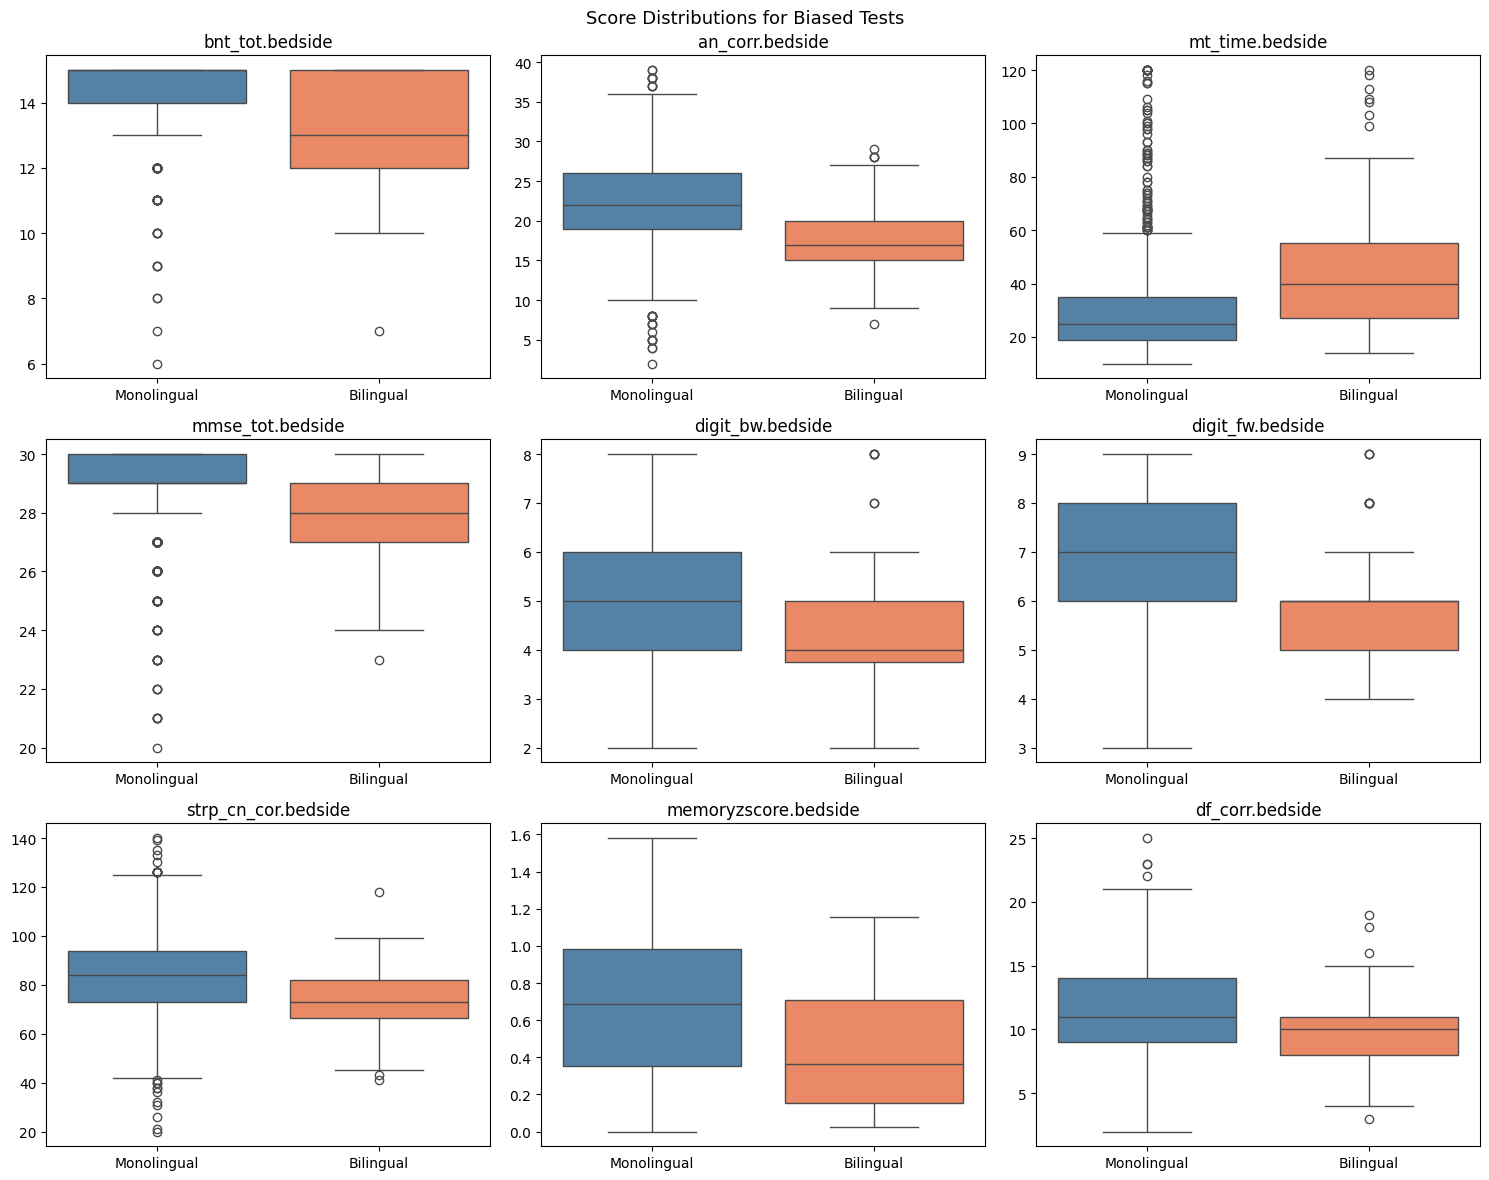

In [20]:
plot_vars = bias_results[bias_results["bias_level"].isin(
    ["LARGE BIAS", "MEDIUM BIAS"])]["test"].tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, var in zip(axes.flat, plot_vars):
    sample = eng[[var, "group"]].dropna()
    sns.boxplot(data=sample, x="group", y=var, ax=ax,
                palette={"Monolingual": "steelblue", "Bilingual": "coral"})
    ax.set_title(var)
    ax.set_ylabel("")
    ax.set_xlabel("")
plt.suptitle("Score Distributions for Biased Tests", fontsize=13)
plt.tight_layout()
plt.savefig("score_distributions.png")
plt.show()

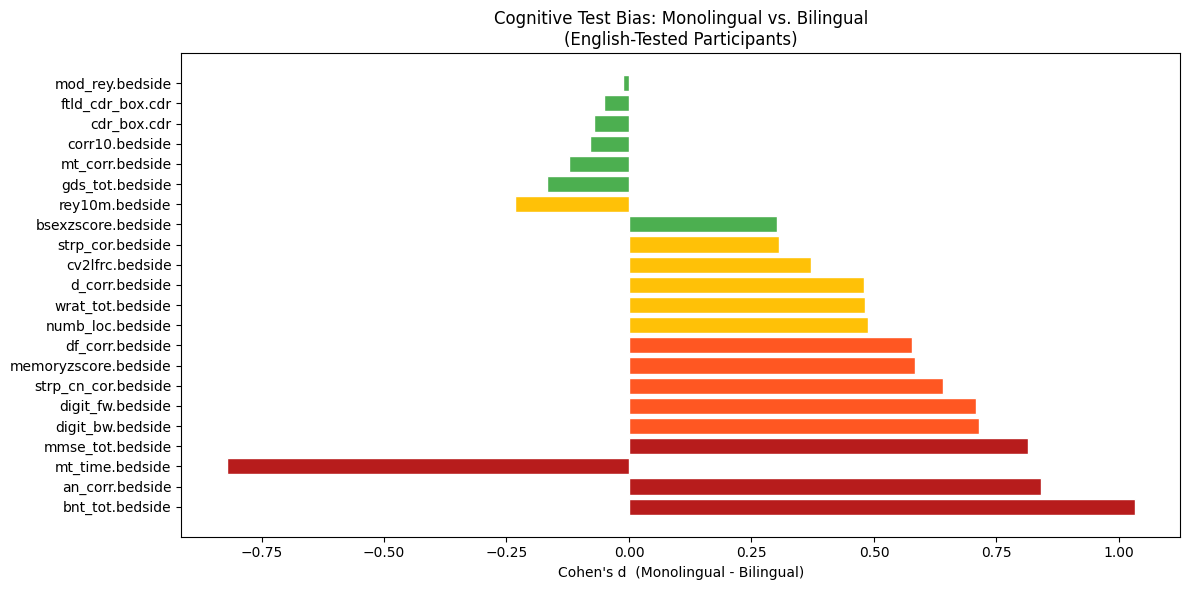

In [9]:
colors = ['#B71C1C' if b == 'LARGE BIAS' else
          '#FF5722' if b == 'MEDIUM BIAS' else
          '#FFC107' if b == 'SMALL BIAS' else
          '#4CAF50'
          for b in bias_results["bias_level"]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(bias_results["test"], bias_results["cohens_d"],
        color=colors, edgecolor="white")
ax.set_xlabel("Cohen's d  (Monolingual - Bilingual)")
ax.set_title("Cognitive Test Bias: Monolingual vs. Bilingual\n(English-Tested Participants)")
plt.tight_layout()
plt.show()

Colors indicate bias level:
- Green = FAIR
- Yellow = SMALL BIAS  
- Orange = MEDIUM BIAS
- Red = LARGE BIAS

In [10]:
#Save outputs
bias_results.to_csv("bias_analysis_cohens_d.csv", index=False)
print("Saved: bias_analysis_cohens_d.csv")

Saved: bias_analysis_cohens_d.csv


## 4. Split Data for Classification

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

features = bias_results["test"].tolist()
subset = eng[features + ["group"]].dropna(subset=["group"])

X = subset[features].values
y = (subset["group"] == "Bilingual").astype(int).values

print(subset["group"].value_counts())
print(f"\nFeatures:        {len(features)}")
print(f"Total samples:   {len(X)}")
print(f"Monolingual (0): {(y == 0).sum()}")
print(f"Bilingual   (1): {(y == 1).sum()}")

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

imputer = SimpleImputer(strategy='median')
X_trainval_imp = imputer.fit_transform(X_trainval)
X_test_imp     = imputer.transform(X_test)

scaler = StandardScaler()
X_trainval_scaled = scaler.fit_transform(X_trainval_imp)
X_test_scaled     = scaler.transform(X_test_imp)

group
Monolingual    1779
Bilingual       185
Name: count, dtype: int64

Features:        22
Total samples:   1964
Monolingual (0): 1779
Bilingual   (1): 185


## 5. Cross-Validation Model Comparison



In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                          verbosity=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross-Validation Results (ROC AUC):\n")

cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_trainval_scaled, y_trainval,
                              cv=cv, scoring='roc_auc')
    for fold, score in enumerate(scores, 1):
        cv_results.append({'model': name, 'fold': fold, 'auc': score})
    print(f"{name}:")
    print(f"  AUC per fold: {scores.round(3)}")
    print(f"  Mean AUC: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})\n")

cv_df = pd.DataFrame(cv_results)
cv_df.pivot(index='fold', columns='model', values='auc').round(3)


5-Fold Cross-Validation Results (ROC AUC):

Logistic Regression:
  AUC per fold: [0.685 0.775 0.711 0.662 0.749]
  Mean AUC: 0.716 (+/- 0.082)

Random Forest:
  AUC per fold: [0.781 0.843 0.822 0.779 0.776]
  Mean AUC: 0.800 (+/- 0.055)

XGBoost:
  AUC per fold: [0.797 0.877 0.807 0.83  0.793]
  Mean AUC: 0.821 (+/- 0.062)



model,Logistic Regression,Random Forest,XGBoost
fold,,,
1,0.685,0.781,0.797
2,0.775,0.843,0.877
3,0.711,0.822,0.807
4,0.662,0.779,0.830
5,0.749,0.776,0.793


Summary:


,mean,std
model,,
Logistic Regression,0.716,0.046
Random Forest,0.800,0.031
XGBoost,0.821,0.035


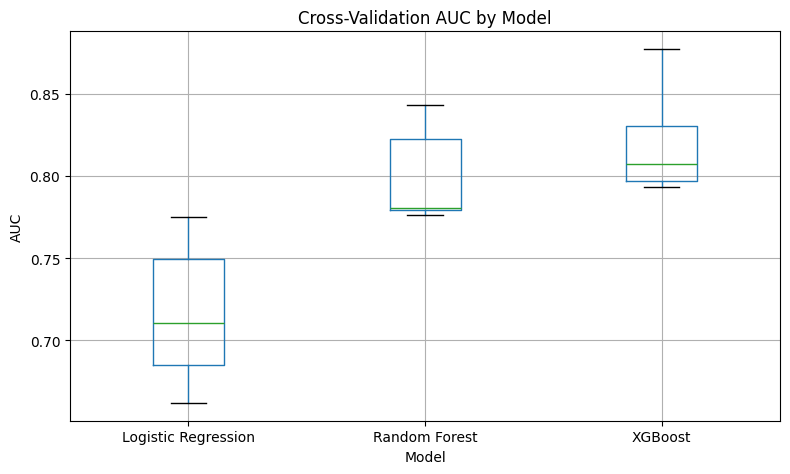

In [13]:
#Summary
print("Summary:")
display(cv_df.groupby('model')['auc'].agg(['mean', 'std']).round(3))

#Visualize Results with Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
cv_df.boxplot(column='auc', by='model', ax=ax)
ax.set_title('Cross-Validation AUC by Model')
ax.set_xlabel('Model')
ax.set_ylabel('AUC')
plt.suptitle('')
plt.tight_layout()
plt.show()


## 6. Train Final Models on Full Train+Validation Set


In [14]:
#Train all models on full trainval data
trained_models = {}
for name, model in models.items():
    model.fit(X_trainval_scaled, y_trainval)
    trained_models[name] = model

#Best model by CV AUC score
best_model_name = cv_df.groupby('model')['auc'].mean().idxmax()
best_model = trained_models[best_model_name]

print(f"Best model by CV AUC: {best_model_name}")


Best model by CV AUC: XGBoost


## 7. Final Evaluation on Test Set

Evaluate on the held-out test set — **this is the first and only time we use this data**.


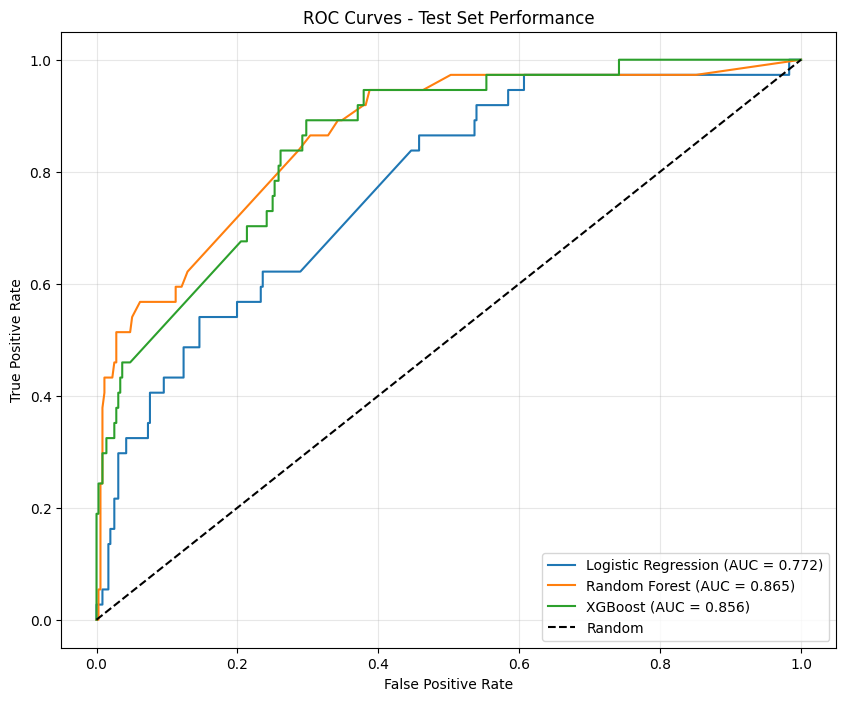


Logistic Regression - Test Set:
              precision    recall  f1-score   support

 Monolingual       0.91      0.99      0.95       356
   Bilingual       0.25      0.03      0.05        37

    accuracy                           0.90       393
   macro avg       0.58      0.51      0.50       393
weighted avg       0.85      0.90      0.86       393


Random Forest - Test Set:
              precision    recall  f1-score   support

 Monolingual       0.91      0.99      0.95       356
   Bilingual       0.50      0.05      0.10        37

    accuracy                           0.91       393
   macro avg       0.71      0.52      0.52       393
weighted avg       0.87      0.91      0.87       393


XGBoost - Test Set:
              precision    recall  f1-score   support

 Monolingual       0.93      0.99      0.96       356
   Bilingual       0.71      0.32      0.44        37

    accuracy                           0.92       393
   macro avg       0.82      0.66      0.70    

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay
)

#Evaluate all models and plot ROC curves
results = {}

plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'auc': auc, 'predictions': y_pred, 'probabilities': y_prob}

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Test Set Performance')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

#Classification reports
for name, result in results.items():
    print(f"\n{name} - Test Set:")
    print(classification_report(y_test, result['predictions'],
                                 target_names=['Monolingual', 'Bilingual']))


## 8. Confusion Matrix for Best Model


Best model: XGBoost


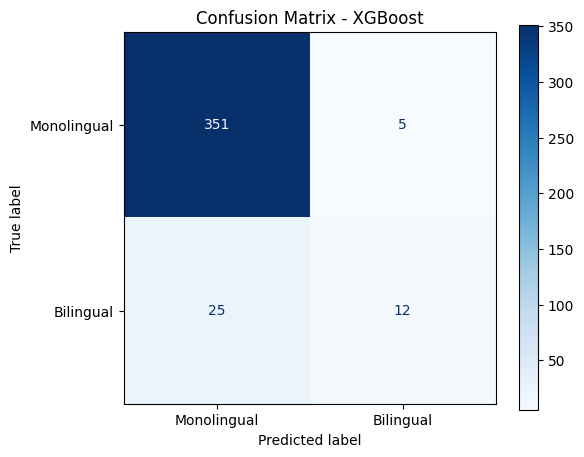

In [16]:
best_predictions = results[best_model_name]['predictions']

print(f"Best model: {best_model_name}")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Monolingual', 'Bilingual'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix - {best_model_name}')
plt.show()


## 9. Comparing CV AUC vs Test AUC

In [17]:
# Compare CV AUC vs Test AUC
cv_summary = cv_df.groupby('model')['auc'].mean().reset_index()
cv_summary.columns = ['model', 'cv_auc']

test_df = pd.DataFrame([
    {'model': name, 'test_auc': res['auc']}
    for name, res in results.items()
])

comparison = cv_summary.merge(test_df, on='model')
comparison['diff'] = (comparison['test_auc'] - comparison['cv_auc']).round(3)
comparison = comparison.round(3)

print("CV AUC vs Test AUC")
display(comparison)


CV AUC vs Test AUC


,model,cv_auc,test_auc,diff
0,Logistic Regression,0.716,0.772,0.055
1,Random Forest,0.800,0.865,0.065
2,XGBoost,0.821,0.856,0.035


## 10. Feature Importance (Random Forest)

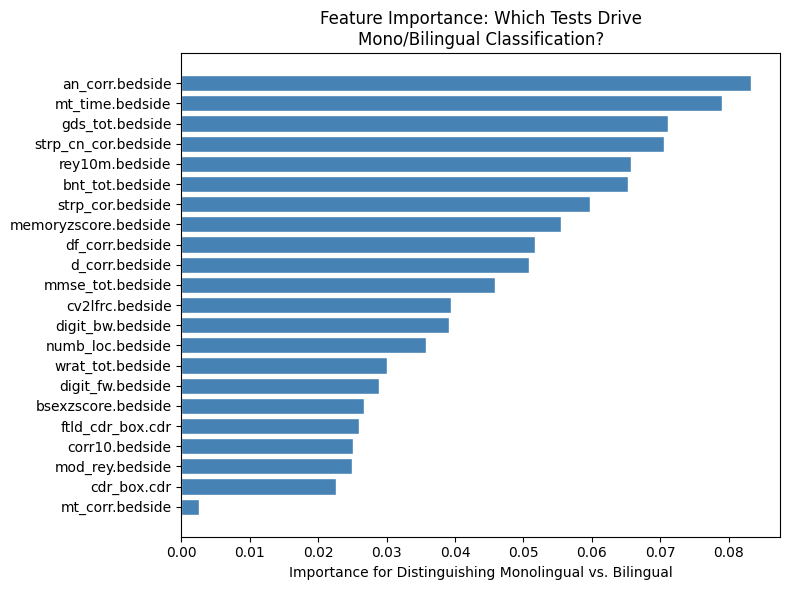


Top 5 most important features:
                feature  importance
1       an_corr.bedside    0.083340
2       mt_time.bedside    0.079059
16      gds_tot.bedside    0.071110
6   strp_cn_cor.bedside    0.070617
15       rey10m.bedside    0.065767


In [18]:
#Get feature importances from Random Forest
rf_model = trained_models['Random Forest']
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'feature':    features,
    'importance': importances
}).sort_values('importance', ascending=True)

#Plot
plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='steelblue', edgecolor='white')
plt.xlabel('Importance for Distinguishing Monolingual vs. Bilingual')
plt.title('Feature Importance: Which Tests Drive\nMono/Bilingual Classification?')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance_df.sort_values('importance', ascending=False).head(5))


## 11. Save Outputs


In [19]:
bias_results.to_csv("bias_analysis_cohens_d.csv", index=False)
comparison.to_csv("model_comparison_results.csv", index=False)

print("Files saved:")
print("bias_analysis_cohens_d.csv")
print("model_comparison_results.csv")
print("bias_cohens_d.png")
print("roc_curves.png")
print("confusion_matrix.png")
print("feature_importance.png")


Files saved:
bias_analysis_cohens_d.csv
model_comparison_results.csv
bias_cohens_d.png
roc_curves.png
confusion_matrix.png
feature_importance.png
